In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv("RFLFSODataFull.csv")

if 'SYNOP' not in df.columns:
    df['SYNOP'] = np.random.choice(['Clear', 'Fog', 'Dust', 'Rain', 'Snow', 'Drizzle', 'Showers'], size=len(df))

label_encoder = LabelEncoder()
df['SYNOP_encoded'] = label_encoder.fit_transform(df['SYNOP'])

target = 'FSO_Att'
features = [col for col in df.columns if col not in ['FSO_Att', 'RFL_Att', 'SYNOP']]
features.append('SYNOP_encoded')

X = df[features]
y = df[target]

rf = RandomForestRegressor(n_estimators=10, random_state=42)
rf.fit(X, y)

df['Estimated_FSO_Attenuation'] = rf.predict(X)

df.drop(columns=['SYNOP_encoded'], inplace=True)

df.to_csv("RFLFSOData_with_Estimated_FSO_Attenuation.csv", index=False)

print(df.head())


    FSO_Att   RFL_Att  AbsoluteHumidity  AbsoluteHumidityMax  \
0  7.913289  6.927868         17.595709            17.615907   
1  7.451176  4.412096         17.549693            17.572415   
2  7.072747  6.268740         17.290230            17.644014   
3  6.949288  4.317853         16.820880            17.066776   
4  7.361052  6.114514         16.813820            17.953974   

   AbsoluteHumidityMin     Distance    Frequency  Particulate  ParticulateMax  \
0            17.340148  2115.338398  83500000000          0.0             0.0   
1            17.299439  2113.999257  73500000000          0.0             0.0   
2            16.037894  2118.689047  83500000000          0.0             0.0   
3            15.895622  2114.632339  73500000000          0.0             0.0   
4            15.227225  2116.786055  83500000000          0.0             0.0   

   ParticulateMin  ...  Time   Visibility  VisibilityMax  VisibilityMin  \
0             0.0  ...     9  65884.51846   72336.362

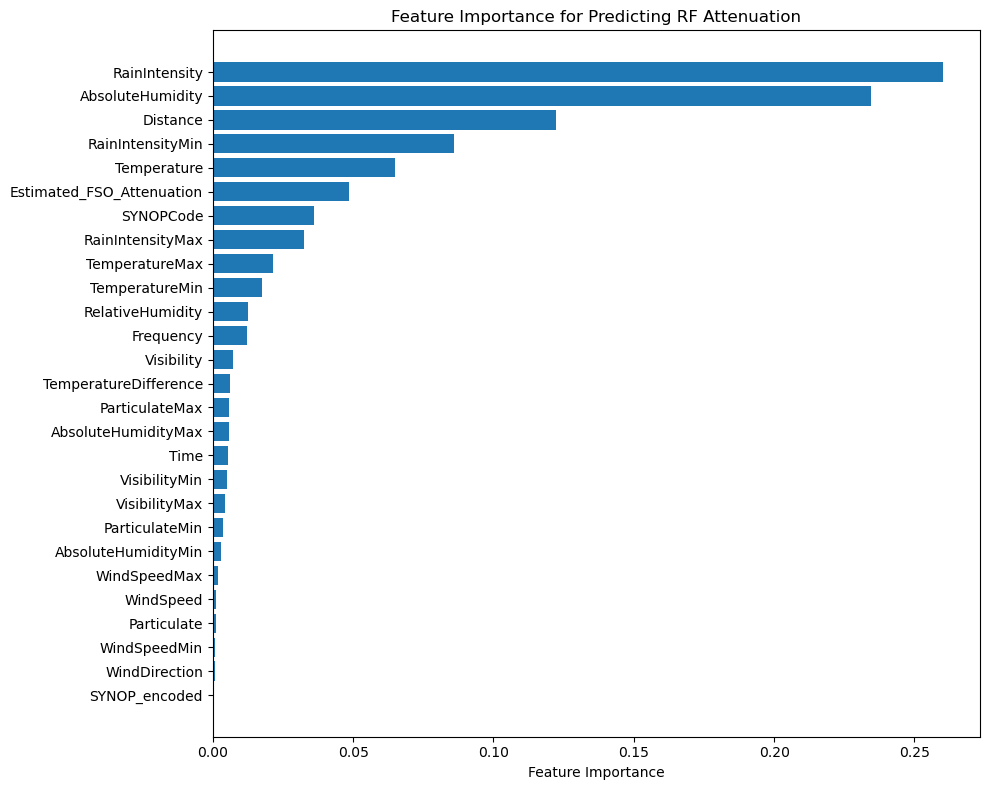

In [2]:
df = pd.read_csv("RFLFSOData_with_Estimated_FSO_Attenuation.csv")

if 'SYNOP' in df.columns:
    label_encoder = LabelEncoder()
    df['SYNOP_encoded'] = label_encoder.fit_transform(df['SYNOP'])
else:
    df['SYNOP_encoded'] = np.random.randint(0, 7, size=len(df))

target = 'RFL_Att'
features = [col for col in df.columns if col not in ['FSO_Att', 'RFL_Att', 'SYNOP']]

X = df[features]
y = df[target]

rf = RandomForestRegressor(n_estimators=10, random_state=42)
rf.fit(X, y)

importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df.sort_values(by='Importance', ascending=True, inplace=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel("Feature Importance")
plt.title("Feature Importance for Predicting RF Attenuation")
plt.tight_layout()
plt.show()

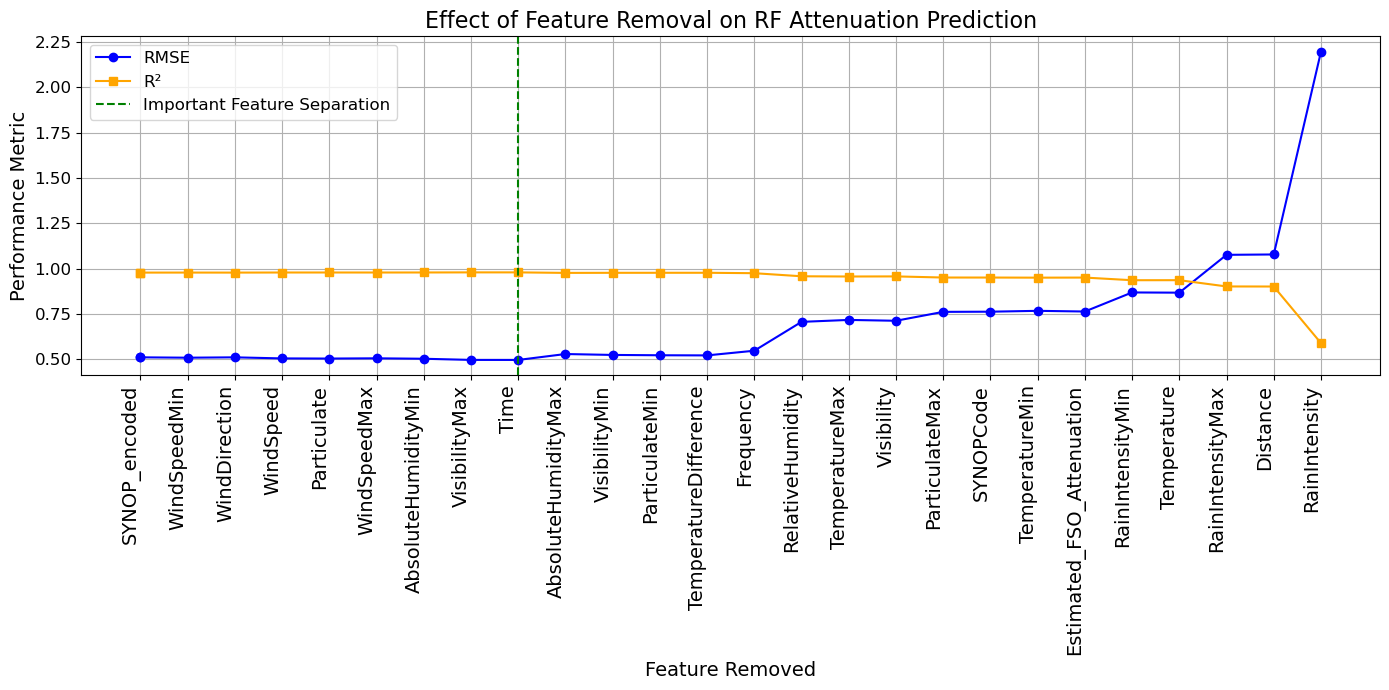

In [5]:
if 'SYNOP' in df.columns:
    label_encoder = LabelEncoder()
    df['SYNOP_encoded'] = label_encoder.fit_transform(df['SYNOP'])
else:
    df['SYNOP_encoded'] = np.random.randint(0, 7, size=len(df))

target = 'RFL_Att'
exclude = ['FSO_Att', 'RFL_Att', 'SYNOP']
features = [col for col in df.columns if col not in exclude]
features.append('SYNOP_encoded')

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

results = []
removed_features = []
current_features = features.copy()

while len(current_features) > 1:
    rf = RandomForestRegressor(n_estimators=100, oob_score=True, bootstrap=True, random_state=42)
    rf.fit(X_train[current_features], y_train)
    y_pred = rf.predict(X_test[current_features])

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    importances = rf.feature_importances_
    feature_importance_pairs = list(zip(current_features, importances))
    if len(feature_importance_pairs) <= 1:
        break

    feature_importance_pairs.sort(key=lambda x: x[1])
    least_important_feature = feature_importance_pairs[0][0]
    current_features.remove(least_important_feature)
    removed_features.append(least_important_feature)

    results.append({
        'feature_removed': least_important_feature,
        'rmse': rmse,
        'r2': r2
    })

feature_names = [r['feature_removed'] for r in results]
rmse_values = [r['rmse'] for r in results]
r2_values = [r['r2'] for r in results]

best_index = np.argmax(r2_values)
best_feature_count = len(features) - (best_index + 1)  # number of features remaining at best R²

plt.figure(figsize=(14, 7))
plt.plot(feature_names, rmse_values, marker='o', color='blue', label='RMSE')
plt.plot(feature_names, r2_values, marker='s', color='orange', label='R²')

plt.axvline(x=feature_names[best_index], color='green', linestyle='--', label='Important Feature Separation')

plt.xlabel("Feature Removed", fontsize=14)
plt.ylabel("Performance Metric", fontsize=14)
plt.title("Effect of Feature Removal on RF Attenuation Prediction", fontsize=16)
plt.xticks(rotation=90, ha='right', fontsize=14)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


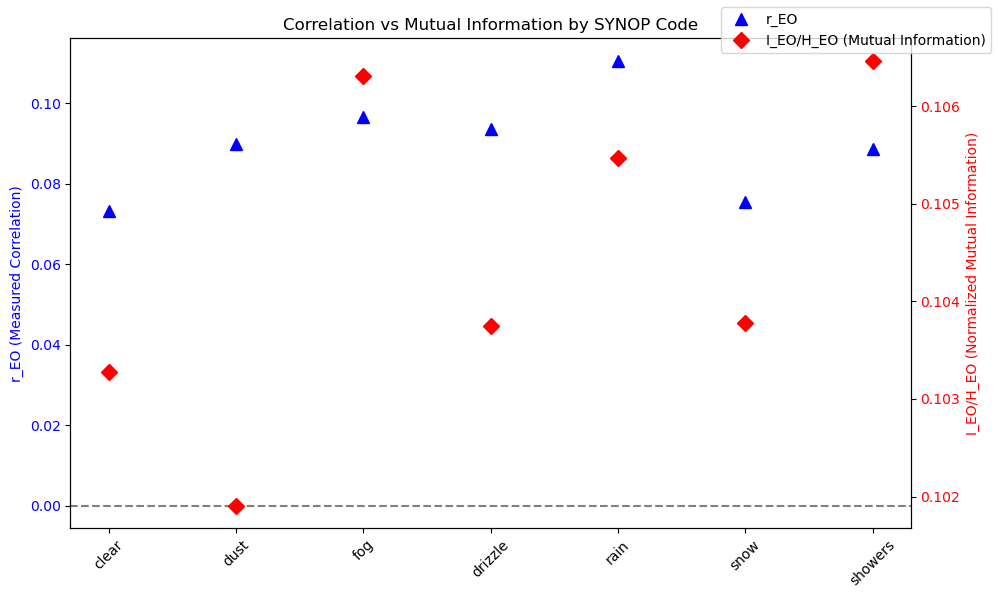

In [18]:
weather_conditions = ['Clear', 'Dust', 'Fog', 'Drizzle', 'Rain', 'Snow', 'Showers']

labels = []
correlations = []
normalized_MI = []

def entropy(p):
    p_nonzero = p[p > 0]
    return -np.sum(p_nonzero * np.log2(p_nonzero))

for weather in weather_conditions:
    subset = df[df['SYNOP'].str.lower() == weather.lower()]
    if subset.empty or len(subset) < 3:
        continue

    x = subset['FSO_Att'].values
    y = subset['RFL_Att'].values

    r, _ = pearsonr(x, y)

    bin_size = 1
    x_bins = np.arange(0, np.ceil(x.max()) + bin_size, bin_size)
    y_bins = np.arange(0, np.ceil(y.max()) + bin_size, bin_size)
    hist2d, _, _ = np.histogram2d(x, y, bins=[x_bins, y_bins])
    Pxy = hist2d / np.sum(hist2d)

    Px = np.sum(Pxy, axis=1)
    Py = np.sum(Pxy, axis=0)
    Hx = entropy(Px)
    Hy = entropy(Py)
    Hxy = entropy(Pxy.flatten())
    MI = Hx + Hy - Hxy

    labels.append(weather.lower())
    correlations.append(r)
    normalized_MI.append(MI / Hx if Hx > 0 else 0)

fig, ax1 = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(labels))

ax1.plot(x_pos, correlations, 'b^', markersize=8, label='r_EO')
ax1.set_ylabel('r_EO (Measured Correlation)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(labels, rotation=45)
ax1.axhline(0, color='gray', linestyle='--')

ax2 = ax1.twinx()
ax2.plot(x_pos, normalized_MI, 'rD', markersize=8, label='I_EO/H_EO (Mutual Information)')
ax2.set_ylabel('I_EO/H_EO (Normalized Mutual Information)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Correlation vs Mutual Information by SYNOP Code")
fig.legend(loc='upper right')
plt.tight_layout()
plt.show()


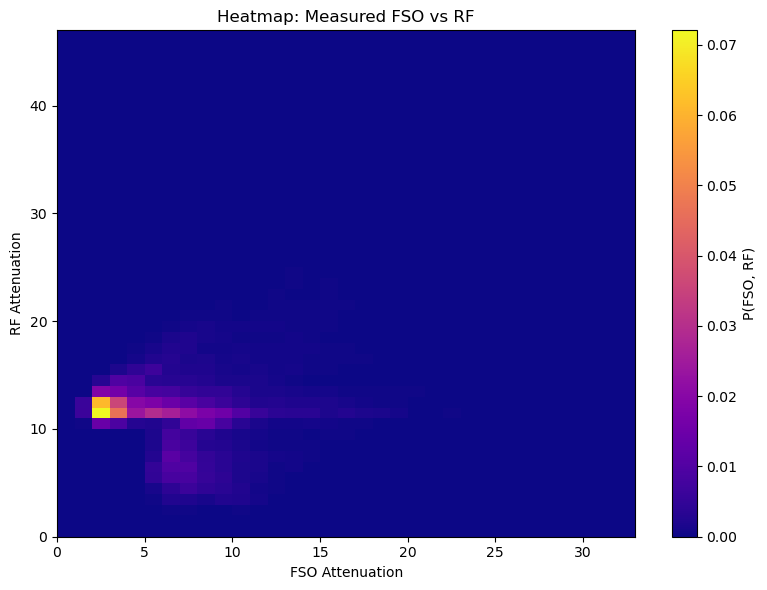

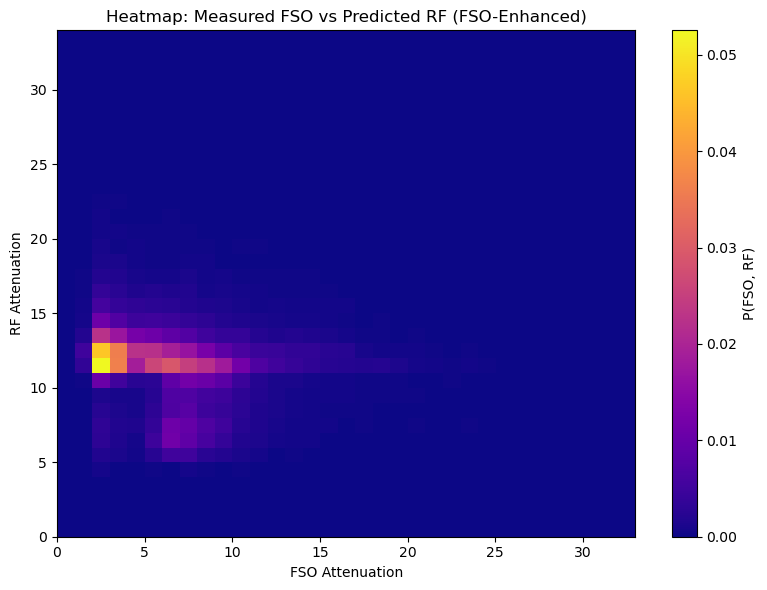

In [16]:
def plot_joint_heatmap(x, y, title):
    bin_size = 1
    x_bins = np.arange(0, np.ceil(x.max()) + bin_size, bin_size)
    y_bins = np.arange(0, np.ceil(y.max()) + bin_size, bin_size)

    hist2d, _, _ = np.histogram2d(y, x, bins=[y_bins, x_bins]) 
    Pxy = hist2d / np.sum(hist2d)

    plt.figure(figsize=(8, 6))
    plt.imshow(Pxy, origin='lower', aspect='auto',
               extent=[x_bins[0], x_bins[-1], y_bins[0], y_bins[-1]],
               cmap='plasma')
    plt.colorbar(label='P(FSO, RF)')
    plt.xlabel("FSO Attenuation")
    plt.ylabel("RF Attenuation")
    plt.title(title)
    plt.tight_layout()
    plt.show()
plot_joint_heatmap(test_df['FSO_Att'], test_df['RFL_Att_measured'], 
                   "Heatmap: Measured FSO vs RF")

plot_joint_heatmap(test_df['FSO_Att'], test_df['RFL_Att_predicted'], 
                   "Heatmap: Measured FSO vs Predicted RF (FSO-Enhanced)")



In [ ]:
if 'SYNOP' in df.columns:
    label_encoder = LabelEncoder()
    df['SYNOP_encoded'] = label_encoder.fit_transform(df['SYNOP'])

target = 'FSO_Att'
features = [col for col in df.columns if col not in ['FSO_Att', 'RFL_Att', 'SYNOP']]
features.append('SYNOP_encoded')

X = df[features]
y = df[target]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
